In [33]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT / "src"))

from compare.plots import (
    plot_lines, plot_eer, plot_f1, plot_pareto, plot_loss_curves, plot_loss_vs_eer,
    plot_gmm_components, plot_gmm_diag_vs_full, _filter,
)

# df = pd.read_parquet(ROOT / "results" / "sweep.parquet.correct")
df = pd.read_parquet(ROOT / "results" / "sweep_pendigits.parquet")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Slide 1: GMM-only comparison

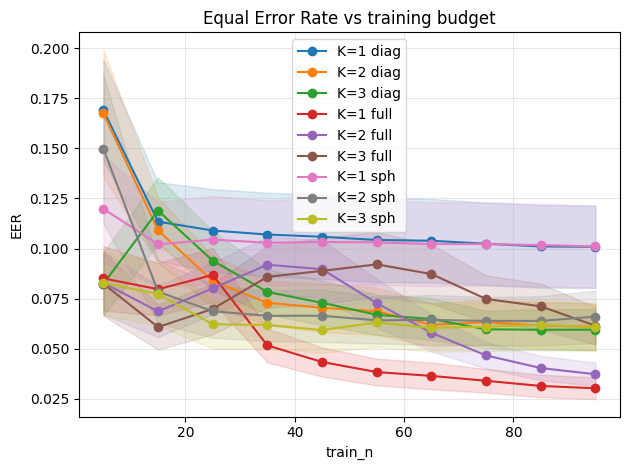

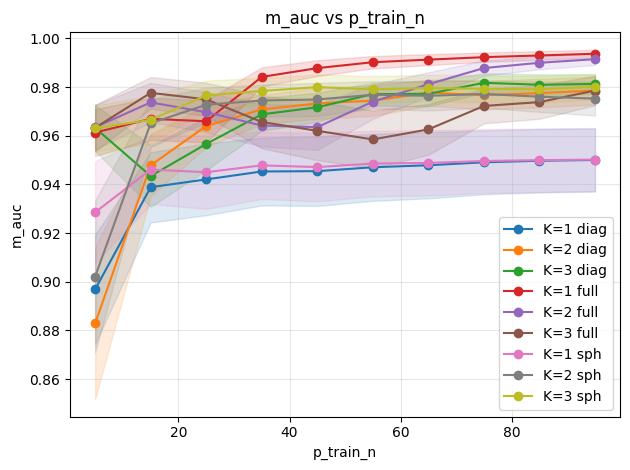

In [34]:
gmm_lines = [
    ("K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),
    ("K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("K=3 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),
]

plot_eer(df, lines=gmm_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=gmm_lines)

# Slide 1b: GMM covariance type comparison

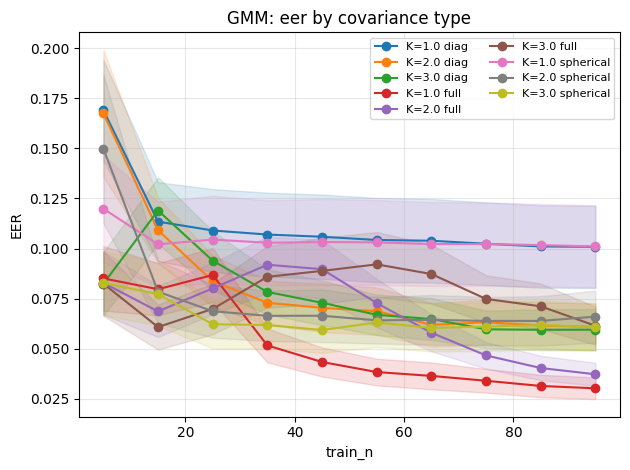

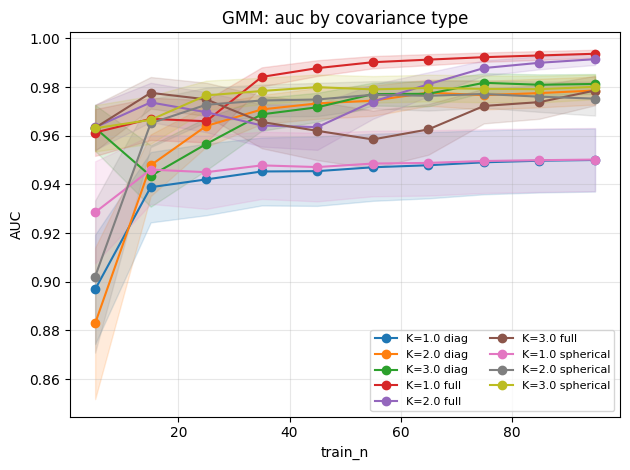

In [35]:
plot_gmm_diag_vs_full(df, y="m_eer")
plot_gmm_diag_vs_full(df, y="m_auc")
plt.show()

# Slide 1c: GMM optimal K

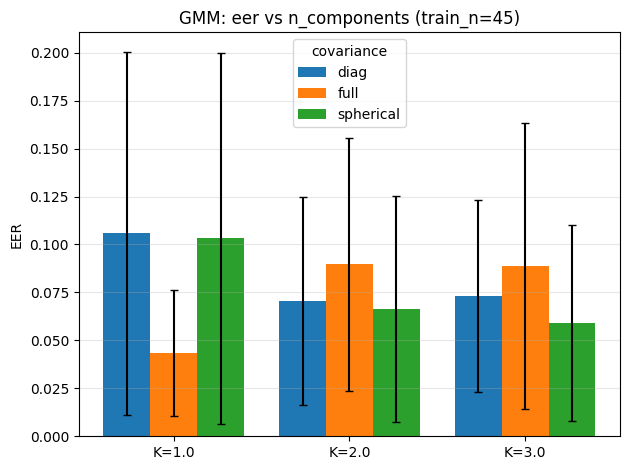

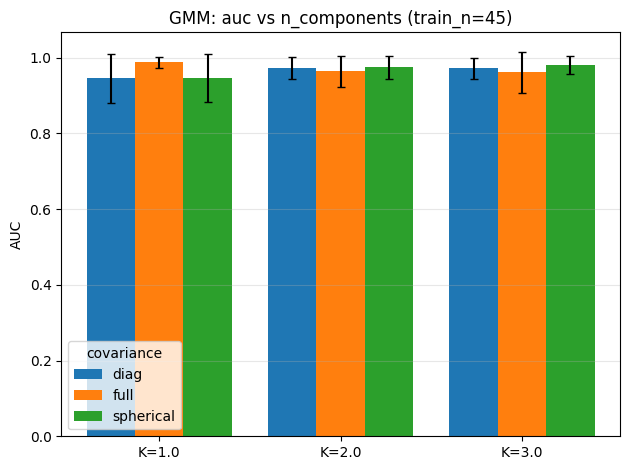

In [36]:
plot_gmm_components(df, y="m_eer", fixed_train_n=45)
plot_gmm_components(df, y="m_auc", fixed_train_n=45)
plt.show()

# Slide 1c-ci: GMM EER and AUC at fixed train_n with 95% CI

Horizontal error-bar plot of GMM configs' EER and AUC at a fixed `train_n`, with 95% confidence intervals across trials x target words.

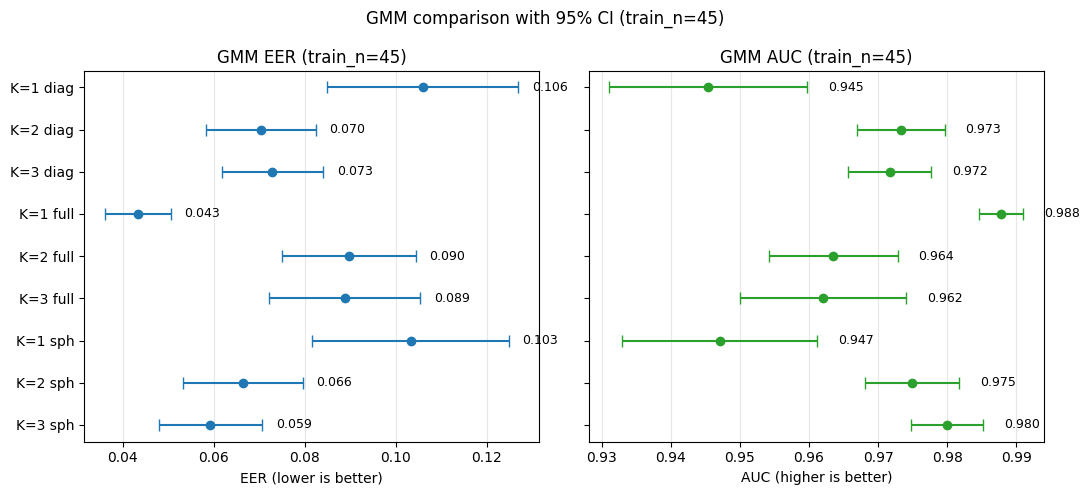

In [37]:
from scipy import stats as _stats
import numpy as np

GMM_CI_TRAIN_N = 45

gmm_ci_configs = [
    ("K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),
    ("K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("K=3 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),
]

sub_gmm_ci = df[df["p_train_n"] == GMM_CI_TRAIN_N]

def _mean_ci95(vals):
    vals = vals.dropna()
    n = len(vals)
    if n < 2:
        return (vals.mean() if n else float("nan"), 0.0)
    sem = vals.std(ddof=1) / np.sqrt(n)
    t_crit = _stats.t.ppf(0.975, df=n - 1)
    return vals.mean(), t_crit * sem

fig, (ax_eer, ax_auc) = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for i, (label, where) in enumerate(gmm_ci_configs):
    s = _filter(sub_gmm_ci, where)
    if s.empty:
        continue
    m_eer, ci_eer = _mean_ci95(s["m_eer"])
    m_auc, ci_auc = _mean_ci95(s["m_auc"])
    ax_eer.errorbar(m_eer, i, xerr=ci_eer, fmt="o", color="tab:blue", capsize=4)
    ax_eer.text(m_eer + ci_eer + 0.003, i, f"{m_eer:.3f}", va="center", fontsize=9)
    ax_auc.errorbar(m_auc, i, xerr=ci_auc, fmt="o", color="tab:green", capsize=4)
    ax_auc.text(m_auc + ci_auc + 0.003, i, f"{m_auc:.3f}", va="center", fontsize=9)

ax_eer.set_yticks(range(len(gmm_ci_configs)))
ax_eer.set_yticklabels([c[0] for c in gmm_ci_configs])
ax_eer.set_xlabel("EER (lower is better)")
ax_eer.set_title(f"GMM EER (train_n={GMM_CI_TRAIN_N})")
ax_eer.invert_yaxis()
ax_eer.grid(axis="x", alpha=0.3)

ax_auc.set_xlabel("AUC (higher is better)")
ax_auc.set_title(f"GMM AUC (train_n={GMM_CI_TRAIN_N})")
ax_auc.grid(axis="x", alpha=0.3)

fig.suptitle(f"GMM comparison with 95% CI (train_n={GMM_CI_TRAIN_N})")
fig.tight_layout()
plt.show()


# Slide 1d: GMM EER per target word (by covariance type)

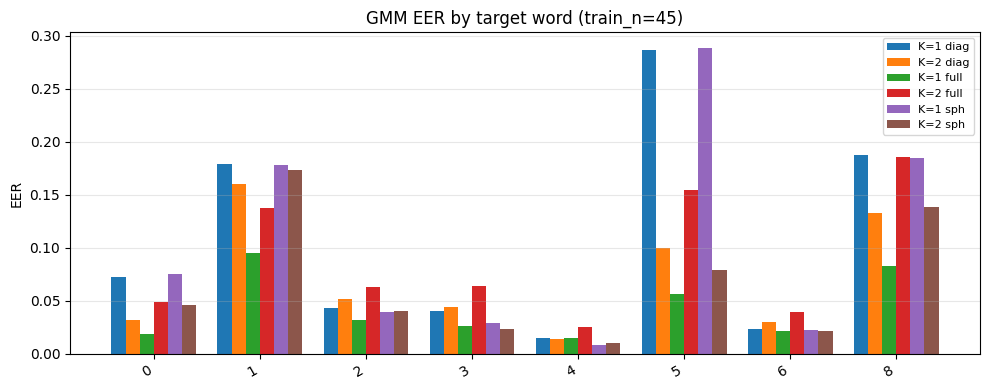

In [38]:
gmm_word_lines = [
    ("K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
]

fixed_train_n = 45
sub = df[df["p_train_n"] == fixed_train_n]
words = sorted(df["p_target_class"].unique())
x = range(len(words))
width = 0.8 / len(gmm_word_lines)

fig, ax = plt.subplots(figsize=(10, 4))
for i, (label, where) in enumerate(gmm_word_lines):
    means = [_filter(sub, where).groupby("p_target_class")["m_eer"].mean().get(w, float("nan")) for w in words]
    offset = (i - len(gmm_word_lines) / 2 + 0.5) * width
    ax.bar([xi + offset for xi in x], means, width=width, label=label)

ax.set_xticks(list(x))
ax.set_xticklabels(words, rotation=30, ha="right")
ax.set_ylabel("EER")
ax.set_title(f"GMM EER by target word (train_n={fixed_train_n})")
ax.legend(fontsize=8)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# Slide 1e: Statistical significance (paired t-tests)

In [39]:
import numpy as np
from scipy import stats

TRAIN_N = 95
sub = df[df["p_train_n"] == TRAIN_N]
idx = ["p_trial", "p_target_class"]

def paired_test(a_eer, b_eer):
    """Return (n, mean_diff, cohen_d, t, p) for b - a."""
    paired = pd.concat([a_eer.rename("a"), b_eer.rename("b")], axis=1).dropna()
    diff = paired["b"] - paired["a"]
    d = diff.mean() / diff.std()
    t, p = stats.ttest_rel(paired["b"], paired["a"])
    return len(paired), diff.mean(), d, t, p

def get_eer(where: dict):
    mask = pd.Series(True, index=sub.index)
    for k, v in where.items():
        if k not in sub.columns:
            return pd.Series(dtype=float)  # column absent: treat as no matching rows
        mask &= sub[k] == v
    return sub[mask].set_index(idx)["m_eer"]

# Define all configs to compare
configs = {
    "GMM K=1 diag": {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"},
    "GMM K=2 diag": {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"},
    "GMM K=3 diag": {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"},
    "GMM K=1 full": {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"},
    "GMM K=2 full": {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"},
    "GMM K=3 full": {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"},
    "GMM K=1 sph":  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"},
    "GMM K=2 sph":  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"},
    "GMM K=3 sph":  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"},
    "SmallAE": {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "train"},
    "kNN k=1":  {"p_adapter": "KNNAdapter", "p_k": 1},
    "kNN k=2":  {"p_adapter": "KNNAdapter", "p_k": 2},
    "kNN k=3":  {"p_adapter": "KNNAdapter", "p_k": 3},
    "kNN k=4":  {"p_adapter": "KNNAdapter", "p_k": 4},
    "kNN k=5":  {"p_adapter": "KNNAdapter", "p_k": 5},
    "kNN k=6":  {"p_adapter": "KNNAdapter", "p_k": 6},
    "kNN k=7":  {"p_adapter": "KNNAdapter", "p_k": 7},
    "kNN k=8":  {"p_adapter": "KNNAdapter", "p_k": 8},
    "kNN k=9":  {"p_adapter": "KNNAdapter", "p_k": 9},
    "kNN k=10": {"p_adapter": "KNNAdapter", "p_k": 10},
}

# All pairwise comparisons
config_names = list(configs.keys())
rows = []
for i in range(len(config_names)):
    for j in range(i + 1, len(config_names)):
        a_name, b_name = config_names[i], config_names[j]
        a_eer = get_eer(configs[a_name])
        b_eer = get_eer(configs[b_name])
        if a_eer.empty or b_eer.empty:
            continue
        n, md, d, t, p = paired_test(a_eer, b_eer)
        rows.append({"A": a_name, "B": b_name, "n_pairs": n,
                      "mean_diff": md, "cohen_d": d, "t_stat": t, "p_value": p})

if rows:
    res = pd.DataFrame(rows)
    res["sig"] = res["p_value"].apply(lambda p: "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns")
    print(f"Paired t-tests on EER at train_n={TRAIN_N}  (is A better than B?)\n")
    print(res.to_string(index=False, float_format="%.4f"))
else:
    print(f"No matching config pairs found in data at train_n={TRAIN_N}."
          " Re-run the sweep with the configs above.")

Paired t-tests on EER at train_n=95  (is A better than B?)

           A            B  n_pairs  mean_diff  cohen_d   t_stat  p_value sig
GMM K=1 diag GMM K=2 diag       80    -0.0400  -0.6545  -5.8544   0.0000 ***
GMM K=1 diag GMM K=3 diag       80    -0.0414  -0.6591  -5.8956   0.0000 ***
GMM K=1 diag GMM K=1 full       80    -0.0707  -0.9558  -8.5490   0.0000 ***
GMM K=1 diag GMM K=2 full       80    -0.0637  -0.8254  -7.3826   0.0000 ***
GMM K=1 diag GMM K=3 full       80    -0.0394  -0.6000  -5.3668   0.0000 ***
GMM K=1 diag  GMM K=1 sph       80     0.0002   0.0320   0.2858   0.7758  ns
GMM K=1 diag  GMM K=2 sph       80    -0.0349  -0.5259  -4.7040   0.0000 ***
GMM K=1 diag  GMM K=3 sph       80    -0.0401  -0.6177  -5.5253   0.0000 ***
GMM K=1 diag      kNN k=1       80    -0.0729  -0.9047  -8.0923   0.0000 ***
GMM K=1 diag      kNN k=2       80    -0.0709  -0.8829  -7.8971   0.0000 ***
GMM K=1 diag      kNN k=3       80    -0.0679  -0.8222  -7.3540   0.0000 ***
GMM K=1 diag    

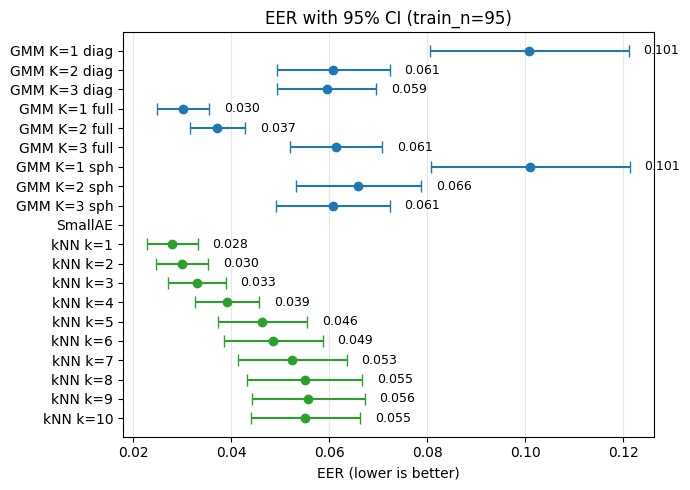

In [40]:
# 95% CI plot for EER at train_n=TRAIN_N (defined in previous cell)
ci_configs = [
    ("GMM K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("GMM K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("GMM K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("GMM K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),
    ("GMM K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("GMM K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("GMM K=3 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "train"}),
    ("kNN k=1",  {"p_adapter": "KNNAdapter", "p_k": 1}),
    ("kNN k=2",  {"p_adapter": "KNNAdapter", "p_k": 2}),
    ("kNN k=3",  {"p_adapter": "KNNAdapter", "p_k": 3}),
    ("kNN k=4",  {"p_adapter": "KNNAdapter", "p_k": 4}),
    ("kNN k=5",  {"p_adapter": "KNNAdapter", "p_k": 5}),
    ("kNN k=6",  {"p_adapter": "KNNAdapter", "p_k": 6}),
    ("kNN k=7",  {"p_adapter": "KNNAdapter", "p_k": 7}),
    ("kNN k=8",  {"p_adapter": "KNNAdapter", "p_k": 8}),
    ("kNN k=9",  {"p_adapter": "KNNAdapter", "p_k": 9}),
    ("kNN k=10", {"p_adapter": "KNNAdapter", "p_k": 10}),
]

colors = {
    "GMMAdapter": "tab:blue",
    "SmallAEAdapter": "tab:orange",
    "KNNAdapter": "tab:green",
}

fig, ax = plt.subplots(figsize=(7, 5))
for i, (label, where) in enumerate(ci_configs):
    if any(k not in sub.columns for k in where):
        continue  # config references a column not present in current results
    mask = pd.Series(True, index=sub.index)
    for k, v in where.items():
        mask &= sub[k] == v
    vals = sub[mask]["m_eer"]
    if vals.empty:
        continue
    mean = vals.mean()
    ci = 1.96 * vals.std() / np.sqrt(len(vals))
    color = colors[where["p_adapter"]]
    ax.errorbar(mean, i, xerr=ci, fmt="o", color=color, capsize=4)
    ax.text(mean + ci + 0.003, i, f"{mean:.3f}", va="center", fontsize=9)

ax.set_yticks(range(len(ci_configs)))
ax.set_yticklabels([c[0] for c in ci_configs])
ax.set_xlabel("EER (lower is better)")
ax.set_title(f"EER with 95% CI (train_n={TRAIN_N})")
ax.invert_yaxis()
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
plt.show()

# Slide 2: Best GMMs vs SmallAE vs kNN

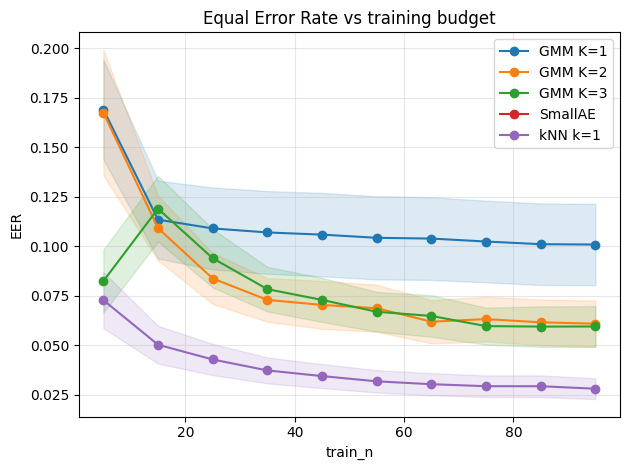

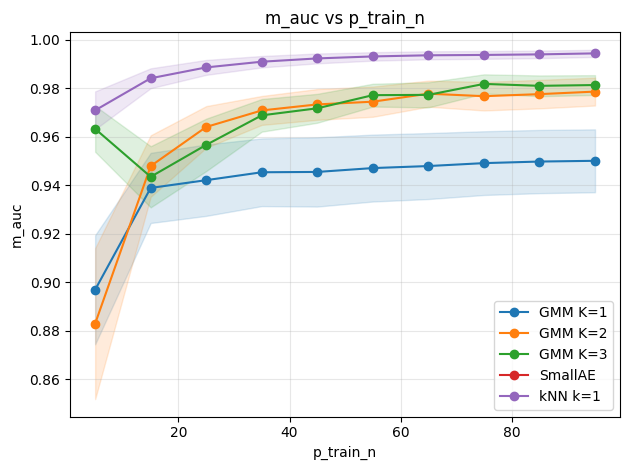

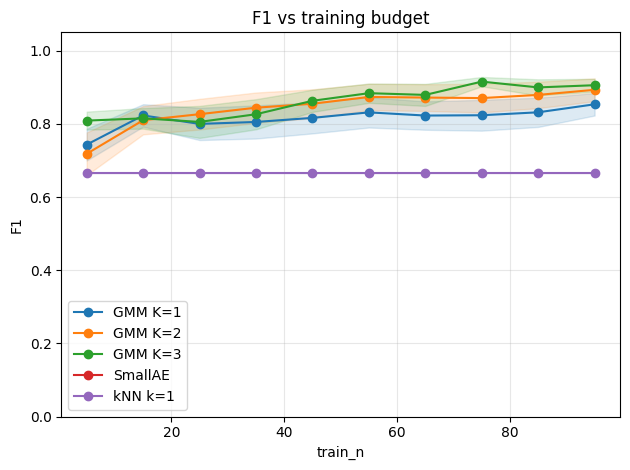

In [41]:
compare_lines = [
    ("GMM K=1",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "train"}),
    ("kNN k=1",  {"p_adapter": "KNNAdapter", "p_k": 1}),
]

plot_eer(df, lines=compare_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=compare_lines)
plot_f1(df, lines=compare_lines)


# Slide 3: Training FLOPs comparison

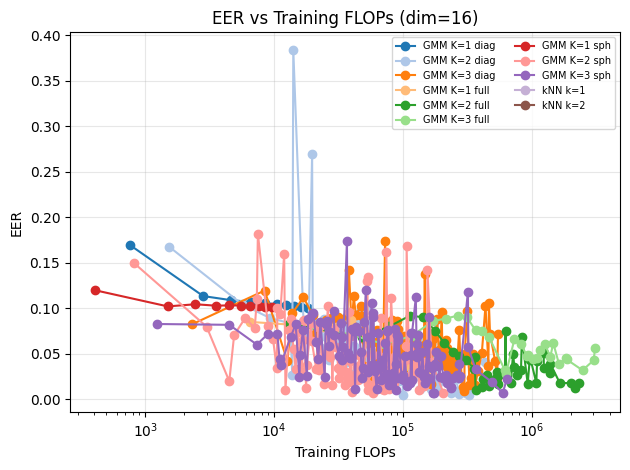

In [42]:
mac_lines = [
    # GMMs -- diag
    ("GMM K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3 diag", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),

    # GMMs -- full
    ("GMM K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("GMM K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("GMM K=3 full", {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "full"}),

    # GMMs -- spherical
    ("GMM K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("GMM K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("GMM K=3 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),

    # kNNs
    ("kNN k=1",      {"p_adapter": "KNNAdapter", "p_k": 1}),
    ("kNN k=2",      {"p_adapter": "KNNAdapter", "p_k": 2}),

    # AEs
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "train"}),
]

from compare.plots import _filter, _agg
import matplotlib.cm as cm

colors = cm.tab20.colors  # 20 distinct colors

for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    ci = 0
    for label, where in mac_lines:
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_training_flops", "m_eer")
        ax.plot(agg["m_training_flops"], agg["mean"], marker="o", label=label, color=colors[ci % len(colors)])
        ci += 1
    ax.set_xscale("log")
    ax.set_xlabel("Training FLOPs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Training FLOPs (dim={dim})")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 3b: Inference FLOPs comparison

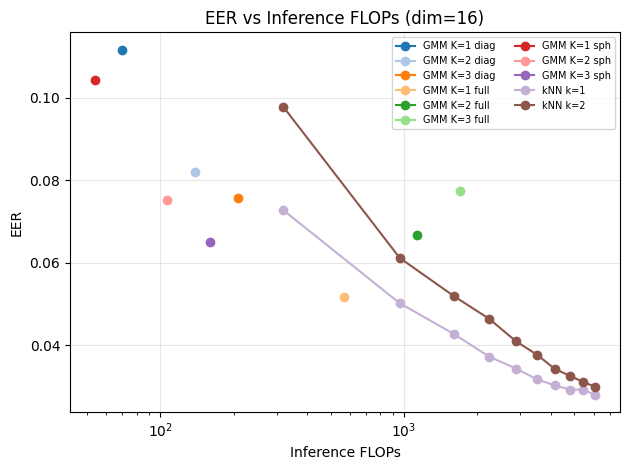

In [43]:
from compare.plots import _filter, _agg
import matplotlib.cm as cm

colors = cm.tab20.colors  # 20 distinct colors

for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    ci = 0
    for label, where in mac_lines:
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_inference_flops", "m_eer")
        ax.plot(agg["m_inference_flops"], agg["mean"], marker="o", label=label, color=colors[ci % len(colors)])
        ci += 1
    ax.set_xscale("log")
    ax.set_xlabel("Inference FLOPs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Inference FLOPs (dim={dim})")
    ax.legend(fontsize=7, ncol=2)
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 4: FLOPs-fair comparison (low-epoch SmallAE vs GMM)

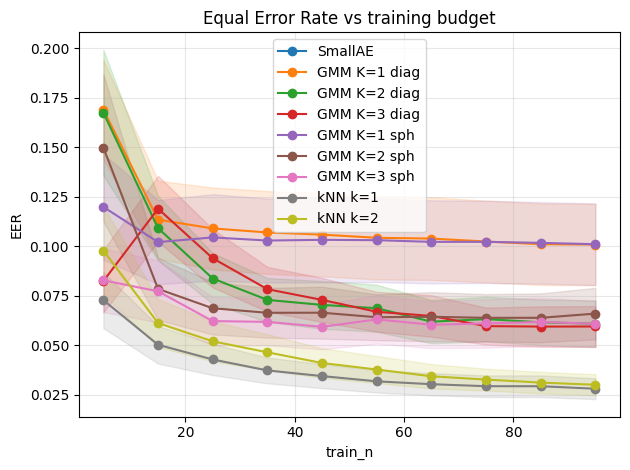

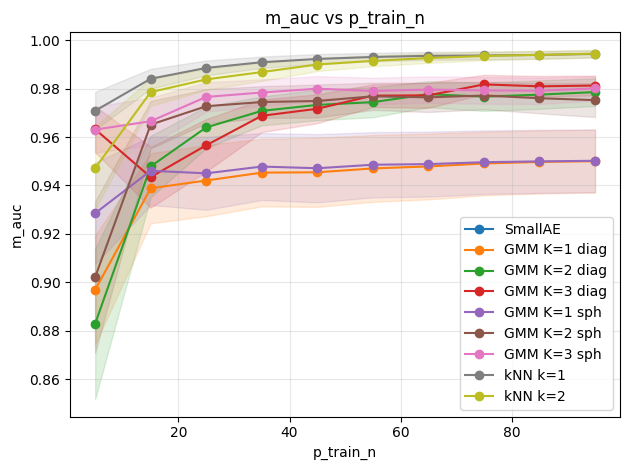

In [44]:
fair_lines = [
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "train"}),
    ("GMM K=1 diag",   {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag",   {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=3 diag",   {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "diag"}),
    ("GMM K=1 sph",    {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("GMM K=2 sph",    {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("GMM K=3 sph",    {"p_adapter": "GMMAdapter", "p_n_components": 3, "p_covariance_type": "spherical"}),
    ("kNN k=1",        {"p_adapter": "KNNAdapter", "p_k": 1}),
    ("kNN k=2",        {"p_adapter": "KNNAdapter", "p_k": 2}),
]

plot_eer(df, lines=fair_lines)
plot_lines(df, x="p_train_n", y="m_auc", lines=fair_lines)

# Slide 4b: ACC at FAR=5% vs enrollment budget

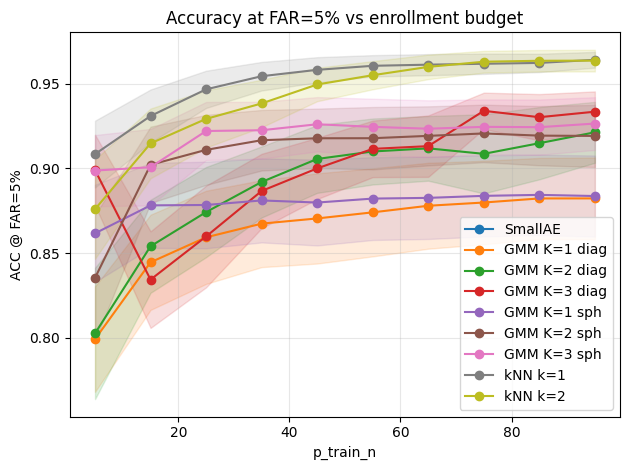

In [45]:
plot_lines(df, x="p_train_n", y="m_acc_at_far5", lines=fair_lines)
plt.ylabel("ACC @ FAR=5%")
plt.title("Accuracy at FAR=5% vs enrollment budget")
plt.show()

# Slide 5: Training FLOPs (low-epoch SmallAE vs GMM)

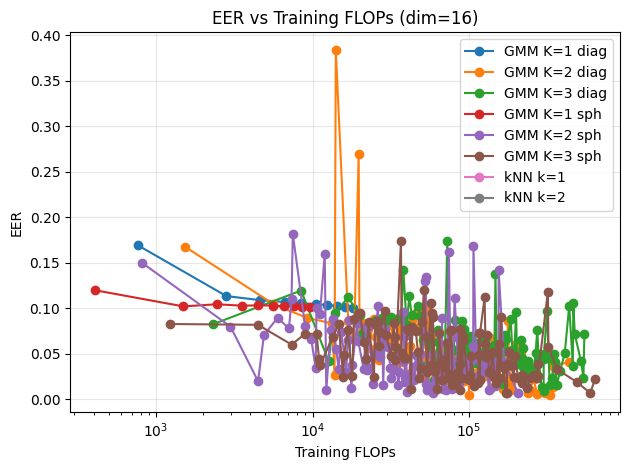

In [46]:
for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    for label, where in fair_lines:
        from compare.plots import _filter, _agg
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_training_flops", "m_eer")
        ax.plot(agg["m_training_flops"], agg["mean"], marker="o", label=label)
    ax.set_xscale("log")
    ax.set_xlabel("Training FLOPs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Training FLOPs (dim={dim})")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 5b: Inference FLOPs (low-epoch SmallAE vs GMM)

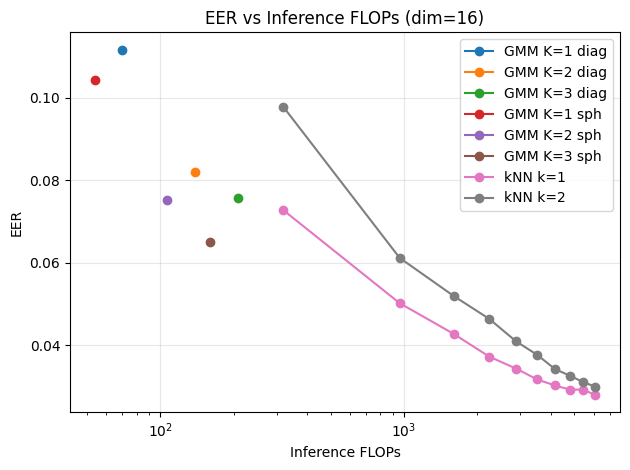

In [47]:
for dim in sorted(df["p_embedding_dim"].unique()):
    fig, ax = plt.subplots()
    for label, where in fair_lines:
        from compare.plots import _filter, _agg
        sub = _filter(df[df["p_embedding_dim"] == dim], where)
        if sub.empty:
            continue
        agg = _agg(sub, "m_inference_flops", "m_eer")
        ax.plot(agg["m_inference_flops"], agg["mean"], marker="o", label=label)
    ax.set_xscale("log")
    ax.set_xlabel("Inference FLOPs")
    ax.set_ylabel("EER")
    ax.set_title(f"EER vs Inference FLOPs (dim={dim})")
    ax.legend()
    ax.grid(alpha=0.3)
    fig.tight_layout()

plt.show()

# Slide 6: EER variance across target words

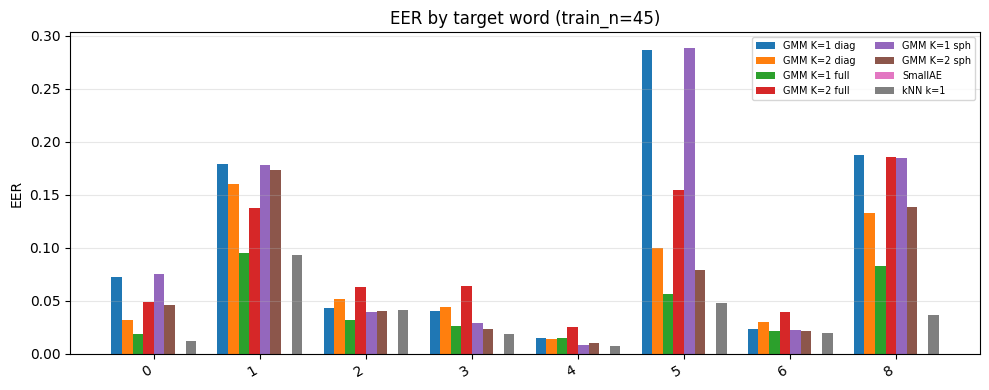

In [48]:
target_lines = [
    ("GMM K=1 diag", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "diag"}),
    ("GMM K=2 diag", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "diag"}),
    ("GMM K=1 full", {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "full"}),
    ("GMM K=2 full", {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "full"}),
    ("GMM K=1 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 1, "p_covariance_type": "spherical"}),
    ("GMM K=2 sph",  {"p_adapter": "GMMAdapter", "p_n_components": 2, "p_covariance_type": "spherical"}),
    ("SmallAE",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "train"}),
    ("kNN k=1",   {"p_adapter": "KNNAdapter", "p_k": 1}),
]

# EER per target word at fixed train_n -- shows which words are harder to enroll
fixed_train_n = 45
sub = df[df["p_train_n"] == fixed_train_n]

fig, ax = plt.subplots(figsize=(10, 4))
words = sorted(df["p_target_class"].unique())
x = range(len(words))
width = 0.8 / len(target_lines)
for i, (label, where) in enumerate(target_lines):
    means = [_filter(sub, where).groupby("p_target_class")["m_eer"].mean().get(w, float("nan")) for w in words]
    offset = (i - len(target_lines) / 2 + 0.5) * width
    ax.bar([xi + offset for xi in x], means, width=width, label=label)

ax.set_xticks(list(x))
ax.set_xticklabels(words, rotation=30, ha="right")
ax.set_ylabel("EER")
ax.set_title(f"EER by target word (train_n={fixed_train_n})")
ax.legend(fontsize=7, ncol=2)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

# Slide 7: Pareto frontier — iso-FLOP comparison

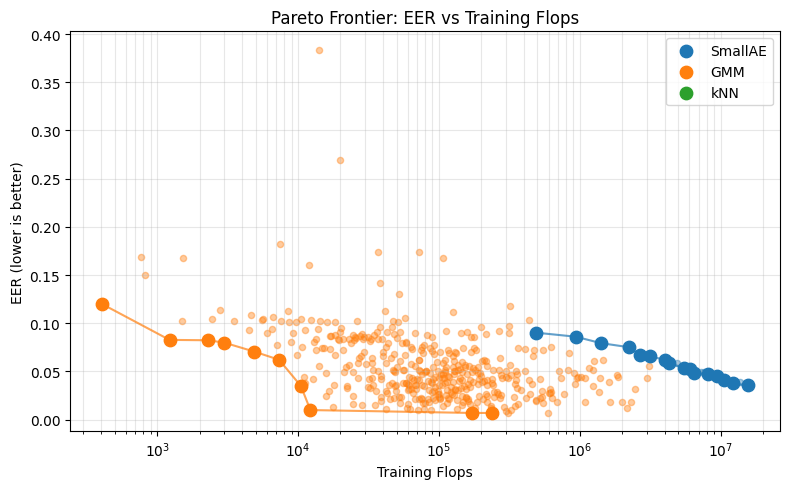

In [49]:
from compare.plots import plot_pareto

pareto_lines = [
    ("SmallAE", {"p_adapter": "SmallAEAdapter"}),
    ("GMM",     {"p_adapter": "GMMAdapter"}),
    ("kNN",     {"p_adapter": "KNNAdapter"}),
]

plot_pareto(df, lines=pareto_lines)
plt.show()

# Slide 7b: Pareto frontier — inference FLOPs

# Slide 8b: threshold_mode — val split vs full-budget training threshold

Does withholding a val split hurt the AE in the micro-data regime?
Compare `threshold_mode=val` (25% held out, threshold on val scores) vs
`threshold_mode=train` (full budget for training, threshold on train scores).

In [50]:
if "p_threshold_mode" not in df.columns:
    print("Skipping threshold_mode ablation: column 'p_threshold_mode' not present in current results.")
else:
    # Threshold-mode ablation: pin dropout_p=0.2 so only threshold_mode varies.
    threshold_lines = [
        ("AE threshold=val",   {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "val"}),
        ("AE threshold=train", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "train"}),
    ]

    plot_eer(df, lines=threshold_lines)
    plt.title("EER: val-split threshold vs full-budget threshold (dropout_p=0.2)")

    plot_lines(df, x="p_train_n", y="m_auc", lines=threshold_lines)
    plt.title("AUC: val-split threshold vs full-budget threshold (dropout_p=0.2)")

    plt.show()

Skipping threshold_mode ablation: column 'p_threshold_mode' not present in current results.


# Slide 8c: dropout — no dropout vs dropout_p=0.2

Does denoising regularisation (dropout during training) help the AE in the micro-data regime?

In [51]:
if "p_dropout_p" not in df.columns:
    print("Skipping dropout ablation: column 'p_dropout_p' not present in current results.")
else:
    # Dropout ablation: pin threshold_mode=train so only dropout varies.
    dropout_lines = [
        ("AE no-dropout",    {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.0, "p_threshold_mode": "train"}),
        ("AE dropout_p=0.2", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30, "p_dropout_p": 0.2, "p_threshold_mode": "train"}),
    ]

    plot_eer(df, lines=dropout_lines)
    plt.title("EER: no dropout vs dropout_p=0.2 (threshold_mode=train)")

    plot_lines(df, x="p_train_n", y="m_auc", lines=dropout_lines)
    plt.title("AUC: no dropout vs dropout_p=0.2 (threshold_mode=train)")

    plt.show()

Skipping dropout ablation: column 'p_dropout_p' not present in current results.


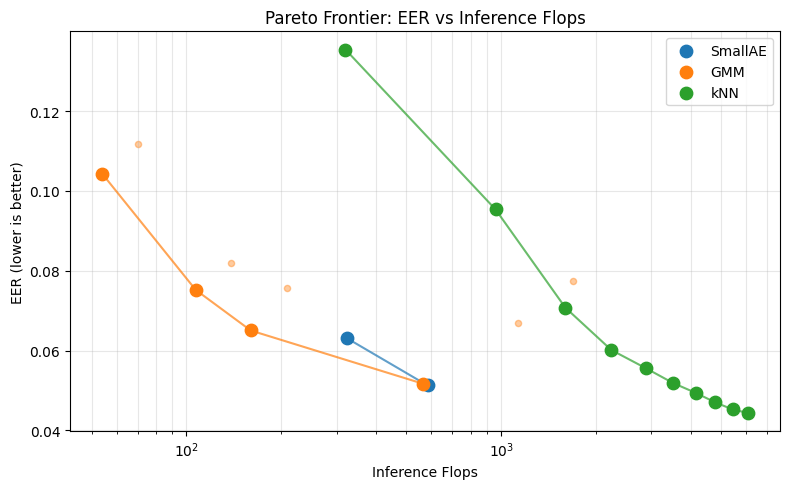

In [52]:
plot_pareto(df, lines=pareto_lines, x="m_inference_flops")
plt.show()

# Slide 8: AE training convergence

TODO: FIXME: the x axis is the percentage of the training wrt the number of iterations.
Make sure to consider this. This should be fixed.

/Users/alberto/Gits/tinygmm/src/compare/plots.py:325: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


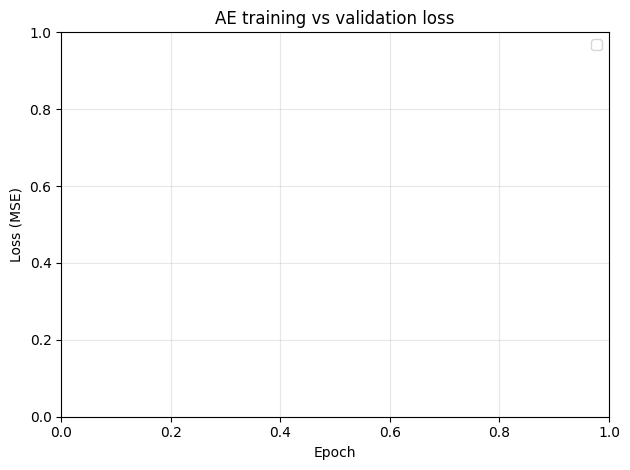

In [53]:
from compare.plots import plot_loss_curves, plot_loss_vs_eer

# Loss curves: is training still improving at the last epoch?
# Each checkpoint is at 20%, 40%, 60%, 80%, 100% of training.
# A line still dropping at x=1.0 means the adapter needs more epochs.
loss_lines = [
    # ("ep=10",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 10}),
    # ("ep=20",  {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 20}),
    ("ep=30", {"p_adapter": "SmallAEAdapter", "p_latent_dim": 4, "p_epochs": 30}),
]

plot_loss_curves(df, lines=loss_lines)
plt.show()

# Final test: held-out TEST_WORDS

Results from `python -m src.compare.test_eval` on the 5 reserved test words (`visual, five, seven, no, off`).
Each test word is scored against the other 4 as adversarial.

In [54]:
import numpy as np
test_df = pd.read_parquet(ROOT / "results" / "test.parquet")
print(f"Loaded {len(test_df)} rows | adapters: {test_df['p_adapter'].unique().tolist()}")
test_df.head()

Loaded 100 rows | adapters: ['GMMAdapter', 'SmallAEAdapter']


,p_split,p_trial,p_embedding_dim,p_target_class,p_other_classes,p_adapter,p_train_n,p_n_components,p_covariance_type,m_recall,...,m_training_flops,p_latent_dim,p_epochs,p_device,p_input_dim,m_loss_1,m_loss_2,m_loss_3,m_loss_4,m_loss_5
0,test,0,16,visual,five|no|off|seven,GMMAdapter,50,1.0,diag,0.875151,...,9472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,test,0,16,visual,five|no|off|seven,SmallAEAdapter,50,NaN,NaN,0.904101,...,8672800,4.0,200.0,mps,16.0,0.313788,0.255622,0.199803,0.152984,0.139956
2,test,1,16,visual,five|no|off|seven,GMMAdapter,50,1.0,diag,0.960796,...,9472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,test,1,16,visual,five|no|off|seven,SmallAEAdapter,50,NaN,NaN,0.882388,...,8672800,4.0,200.0,mps,16.0,0.667179,0.280535,0.264564,0.258926,0.252423
4,test,2,16,visual,five|no|off|seven,GMMAdapter,50,1.0,diag,0.967431,...,9472,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Summary metrics (mean +/- std across trials x target words)

In [55]:
metrics = ["m_eer", "m_auc", "m_auprc", "m_f1", "m_acc_at_far5"]
metrics = [m for m in metrics if m in test_df.columns]
summary = test_df.groupby("p_adapter")[metrics].agg(["mean", "std"]).round(4)
summary

m_eer           m_auc         m_auprc            m_f1  \
                  mean     std    mean     std    mean     std    mean   
p_adapter                                                                
GMMAdapter      0.0877  0.0318  0.9676  0.0169   0.991  0.0065  0.9349   
SmallAEAdapter  0.1243  0.1045  0.9343  0.1179   0.978  0.0557  0.8700   

                       m_acc_at_far5          
                   std          mean     std  
p_adapter                                     
GMMAdapter      0.0419        0.8781  0.0552  
SmallAEAdapter  0.1840        0.8113  0.1470

## EER bar chart with 95% CI

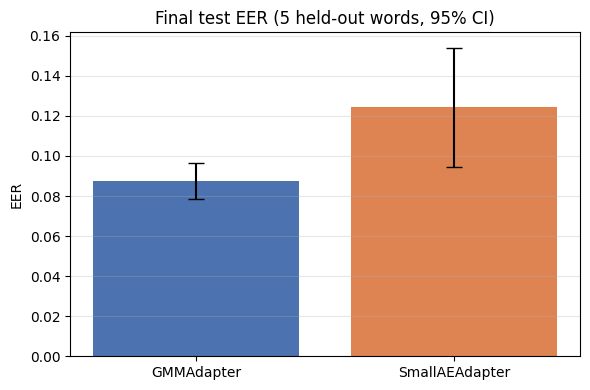

In [56]:
from scipy import stats as _stats

fig, ax = plt.subplots(figsize=(6, 4))
adapters = sorted(test_df["p_adapter"].unique())
means, margins = [], []
for a in adapters:
    vals = test_df.loc[test_df["p_adapter"] == a, "m_eer"].dropna()
    n = len(vals)
    m = vals.mean()
    sem = vals.std(ddof=1) / np.sqrt(n)
    t_crit = _stats.t.ppf(0.975, df=n - 1)
    means.append(m)
    margins.append(t_crit * sem)

ax.bar(adapters, means, yerr=margins, capsize=6, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("EER")
ax.set_title("Final test EER (5 held-out words, 95% CI)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## Paired t-test: GMM vs AE on EER

In [57]:
idx = ["p_trial", "p_target_class"]
gmm_eer = test_df[test_df["p_adapter"] == "GMMAdapter"].set_index(idx)["m_eer"]
ae_eer  = test_df[test_df["p_adapter"] == "SmallAEAdapter"].set_index(idx)["m_eer"]
paired = pd.concat([gmm_eer.rename("gmm"), ae_eer.rename("ae")], axis=1).dropna()
diff = paired["ae"] - paired["gmm"]
t, p = _stats.ttest_rel(paired["ae"], paired["gmm"])
cohen_d = diff.mean() / diff.std(ddof=1)
print(f"n={len(paired)}  mean(AE-GMM)={diff.mean():+.4f}  cohen_d={cohen_d:+.3f}  t={t:+.3f}  p={p:.4g}")

n=50  mean(AE-GMM)=+0.0367  cohen_d=+0.356  t=+2.519  p=0.0151


## EER distribution (boxplot)

Distribution across all 5 target words x 10 trials = 50 runs per adapter.

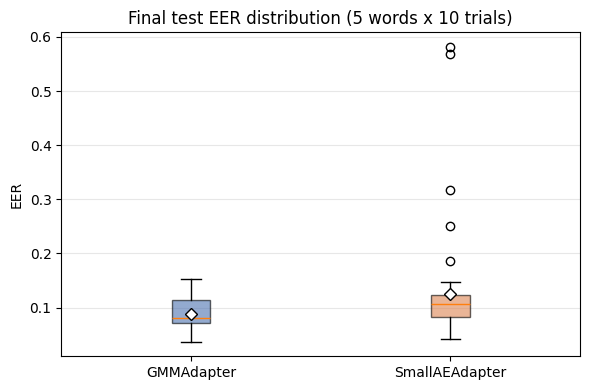

In [58]:
fig, ax = plt.subplots(figsize=(6, 4))
adapters = sorted(test_df["p_adapter"].unique())
data = [test_df.loc[test_df["p_adapter"] == a, "m_eer"].dropna().values for a in adapters]
bp = ax.boxplot(data, tick_labels=adapters, patch_artist=True, showmeans=True,
                meanprops={"marker": "D", "markerfacecolor": "white", "markeredgecolor": "black"})
for patch, color in zip(bp["boxes"], ["#4C72B0", "#DD8452"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
ax.set_ylabel("EER")
ax.set_title("Final test EER distribution (5 words x 10 trials)")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

## FAR vs Recall scatter

One point per (trial, target_word) — shows operating-point calibration spread.

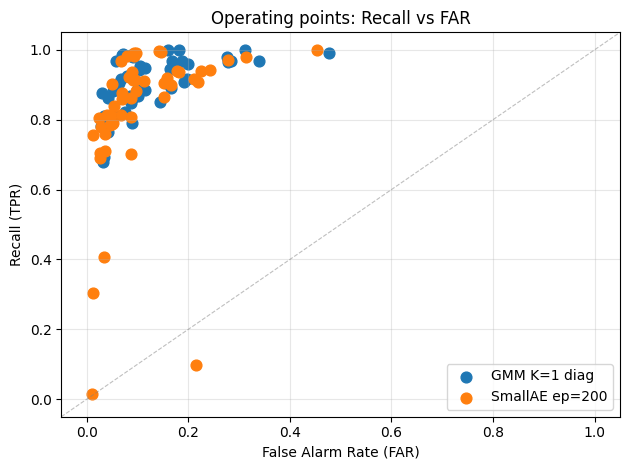

In [59]:
from compare.plots import plot_far_recall

test_lines = [
    ("GMM K=1 diag",   {"p_adapter": "GMMAdapter"}),
    ("SmallAE ep=200", {"p_adapter": "SmallAEAdapter"}),
]
plot_far_recall(test_df, lines=test_lines)
plt.show()